In [1]:
import pandas as pd
import os, json, time
from dotenv import load_dotenv
from openai import OpenAI
import textwrap
import requests

import requests, json, textwrap

# Create a session that ignores proxy env vars (bypasses VPN for local Ollama)
SESSION = requests.Session()
SESSION.trust_env = False  # equivalent of ollama.Client(..., trust_env=False)


def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        

load_dotenv(r"C:\Users\arunk\OneDrive\Documents\GenAI\LLM\openai_key.env")  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

MODEL = 'gpt-5-nano'




client = OpenAI(api_key=api_key)
pretty_print("OpenAI client ready.")

print(f"Using model: {MODEL}")

API key loaded successfully.
OpenAI client ready.
Using model: gpt-5-nano


In [2]:
from langchain.chat_models import init_chat_model

# This uses the Responses API automatically!
llm = init_chat_model(f"openai:{MODEL}", api_key=api_key, temperature=0)

# Simple invocation
response = llm.invoke("Why is Donald Trump so bent on making my portfolio look so red?")
print(response.content)
print()
print(f"Model type: {type(llm).__name__}")

C:\Users\arunk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Short answer: it isn’t personal. Markets move on expectations, news, and how investors think policies will affect profits and economic conditions. President Donald Trump’s policy moves and rhetoric have introduced a lot of uncertainty and sector-specific signals that can cause stocks to swing, which sometimes shows up as red days in a portfolio. But many factors—global growth, interest rates, earnings, geopolitical events, and more—drive market performance too.

Here’s how policy signals from his administration have tended to influence markets, in broad terms:
- Trade policy and tariffs: Changes or threats can raise costs for companies, disrupt supply chains, and shift consumer prices. That tends to make investors nervey about those stocks and sectors, especially manufacturing, technology, and consumer staples.
- Tax and regulation expectations: Proposals around corporate taxes, repatriation of profits, or deregulation can boost some sectors (like financials or energy) while creating u

In [3]:
from langchain_openai import ChatOpenAI

# Explicit Responses API opt-in
llm_explicit = ChatOpenAI(model=MODEL, api_key=api_key, temperature=0, use_responses_api=True) # temperature is optional, just for demonstration not being used in responses API

response = llm_explicit.invoke("Why is Donald Trump so bent on making my portfolio look so red?")
print(response.content)

[{'id': 'rs_0bb4cbd3904e08a70069b6e3ac61bc819caf312dc6e3631eb1', 'summary': [], 'type': 'reasoning'}, {'type': 'text', 'text': 'Short answer: not literally Trump alone, but political policy and rhetoric can move markets. A single figure doesn’t “make” your portfolio red, but expectations about policy can cause volatility and shifts in prices that show up as red on a chart.\n\nHow politics can influence portfolios\n- Policy proposals and regulatory changes can affect earnings and risk. For example, trade talks, tariffs, tax proposals, or deregulation can change costs, margins, and growth outlooks for certain sectors.\n- Markets price in expectations. Even before a policy is enacted, investors adjust positions based on what they think will happen, which can push some holdings down (or up) in the short term.\n- Some sectors are more sensitive. Industrials, energy, financials, tech, or consumer staples can react differently depending on the policy angle (taxation, regulation, trade).\n\nWa

In [5]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="You are a friendly NovaMart customer support agent. Keep answers brief."),
    HumanMessage(content="What's your return policy?")
]

response = llm.invoke(messages)
print(response.content)

Here’s our general return policy:

- 30 days from delivery to start a return.
- Item must be unused, in original condition/packaging, with proof of purchase.
- Some items aren’t eligible (final sale, personalized items, digital downloads, gift cards).
- You pay return shipping unless the item arrived damaged/ incorrect.
- Refunds go to the original payment method after we receive and inspect the item (typically 5–10 business days).
- Exchanges available if in stock; otherwise we’ll issue a refund.

Want me to check your specific order and guide you through the return? If you share your order number, I’ll help right away.


In [6]:
messages = [
    SystemMessage(content="You are a friendly NovaMart customer support agent. Keep answers brief."),
    HumanMessage(content="What's your return policy?"),
    AIMessage(content="You can return most items within 30 days with the receipt."),
    HumanMessage(content="What if I opened the package?")
]

response = llm.invoke(messages)
print(response.content)

Opening the package doesn’t automatically exclude a return. Most items can be returned within 30 days with the receipt if they’re in original, unused condition and packaging. If it’s opened and used or not in original condition, it may be inspected and could incur a restocking fee or be ineligible—some items are exceptions. Want me to check your specific item? Please share your order number and the item. You can also start a return in your account or bring it to a store.


In [7]:
messages = [
	{"role": "system", "content": "You are a friendly NovaMart customer support agent. Keep answers brief."},
	{"role": "user", "content": "What's your return policy?"},
    {"role": "assistant", "content": "You can return most items within 30 days with the receipt."},
    {"role": "user", "content": "What if I opened the package?"}
]

response = llm.invoke(messages)

print(response.content)

Opened packages are fine as long as the item is unused and in its original condition with all packaging and accessories, returned within 30 days with the receipt.

If it’s opened and used or missing parts, it may not be eligible or could incur a restocking fee. Some items are final sale.

Tell me your order number and item, and I’ll confirm eligibility and help start the return.


Tools

In [8]:
from langchain.tools import tool

NOVAMART_FAQ = {
    "return policy": "NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.",
    "shipping time": "Standard shipping takes 3-5 business days. Express shipping takes 1-2 business days.",
    "payment methods": "We accept Visa, Mastercard, PayPal, and NovaPay wallet.",
    "warranty": "All electronics come with a 1-year manufacturer warranty. Extended warranty available for $29/year.",
    "contact": "Email: help@novamart.com | Phone: 1-800-NOVA | Live chat available 24/7.",
}

# ----- NovaMart Order Database -----
NOVAMART_ORDERS = {
    "NM-90210": {"status": "shipped", "eta": "March 15", "item": "Wireless Headphones", "carrier": "FedEx"},
    "NM-10042": {"status": "processing", "eta": "March 18", "item": "Smart Watch Pro", "carrier": "TBD"},
    "NM-55331": {"status": "delivered", "eta": "March 10", "item": "USB-C Hub", "carrier": "UPS"},
}

@tool
def faq_lookup(topic: str) -> str:
    """Look up NovaMart FAQ by topic. Available topics: return policy, shipping time, payment methods, warranty, contact."""
    result = NOVAMART_FAQ.get(topic.lower(), None)
    if result:
        return result
    return f"No FAQ entry found for '{topic}'. Available topics: {', '.join(NOVAMART_FAQ.keys())}"



@tool
def order_tracker(order_id: str) -> str:
    """Track a NovaMart order by its ID (e.g., NM-90210)."""
    order = NOVAMART_ORDERS.get(order_id.upper(), None)
    if order:
        return f"Order {order_id}: {order['item']} — Status: {order['status']}, ETA: {order['eta']}, Carrier: {order['carrier']}"
    return f"Order {order_id} not found. Please double-check the order ID."



# Quick test — calling tools directly
print(faq_lookup.invoke({"topic": "return policy"}))
print()
print(order_tracker.invoke({"order_id": "NM-90210"}))

NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

Order NM-90210: Wireless Headphones — Status: shipped, ETA: March 15, Carrier: FedEx


In [9]:
llm_with_tools = llm.bind_tools([faq_lookup, order_tracker])

In [11]:
response = llm_with_tools.invoke("Where is my order NM-90210?")

In [12]:
print("Content:", response.content)
print()
print("Tool calls:", response.tool_calls)

Content: 

Tool calls: [{'name': 'order_tracker', 'args': {'order_id': 'NM-90210'}, 'id': 'call_r6OPGE02759GiZEQE1qwPvCJ', 'type': 'tool_call'}]


LangChain Agent

In [13]:
from langchain.agents import create_agent

support_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful."
)

print("✅ Agent created! Type:", type(support_agent).__name__)

✅ Agent created! Type: CompiledStateGraph


In [14]:
result = support_agent.invoke(
    {"messages": [{"role": "user", "content": "Hi! Can you check where my order NM-90210 is?"}]}
)

for msg in result["messages"]:
    role = msg.__class__.__name__
    content = str(msg.content)[:200] if msg.content else "(tool call)"
    print(f"[{role}] {content}")
    print()

[HumanMessage] Hi! Can you check where my order NM-90210 is?

[AIMessage] (tool call)

[ToolMessage] Order NM-90210: Wireless Headphones — Status: shipped, ETA: March 15, Carrier: FedEx

[AIMessage] Great news—your order NM-90210 has shipped.

- Item: Wireless Headphones
- Status: Shipped
- Carrier: FedEx
- ETA: March 15

The tracking number isn’t shown here. Would you like me to fetch the tracki



In [15]:
for event in support_agent.stream(
    {"messages": [{"role": "user", "content": "Tell me status of order NM-55331. I need to return order NM-55331. What's the return policy?"}]},
    stream_mode="updates"
):
    for node_name, node_output in event.items():
        print(f"--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                role = msg.__class__.__name__
                content = str(msg.content) if msg.content else "(tool call request)"
                # If this is an AI message and it requested tool calls
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    print("    Tool calls:")
                    for tc in msg.tool_calls:
                        print(f"      - tool name: {tc.get('name')}")
                        print(f"        args: {tc.get('args')}")
                        print(f"        id: {tc.get('id')}")
                print(f"  [{role}] {content}")
        print()

--- model ---
    Tool calls:
      - tool name: order_tracker
        args: {'order_id': 'NM-55331'}
        id: call_3YTydoP5RcYY1v79DhgPiyQV
      - tool name: faq_lookup
        args: {'topic': 'return policy'}
        id: call_PQIENCl8NTvUdNgHkeoQdVsM
  [AIMessage] (tool call request)

--- tools ---
  [ToolMessage] Order NM-55331: USB-C Hub — Status: delivered, ETA: March 10, Carrier: UPS

--- tools ---
  [ToolMessage] NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

--- model ---
  [AIMessage] Here you go:

- Order NM-55331 status: USB-C Hub has been delivered. Delivered March 10 via UPS.
- Return policy: 30-day no-questions-asked return for all items in original packaging.

Return window: You have until April 9, 2026 to return it (30 days from delivery).

How to return:
- Log in to your NovaMart account > Orders > NM-55331 > Start Return.
- Choose a reason, package the item in its original packaging, and follow the prompts to obtain

Wheather Tool

In [16]:
GEOCODE_URL = "https://geocoding-api.open-meteo.com/v1/search"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

WEATHER_CODE_MAP = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snow fall",
    73: "Moderate snow fall",
    75: "Heavy snow fall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail",
}


@tool
def get_weather(location: str) -> str:
    """Get the current weather for a city using Open-Meteo."""
    try:
        # 1) Geocode the location name -> lat/lon
        geo_resp = SESSION.get(
            GEOCODE_URL,
            params={"name": location, "count": 1, "language": "en", "format": "json"},
            timeout=15,
        )
        geo_resp.raise_for_status()
        geo_data = geo_resp.json()

        results = geo_data.get("results")
        if not results:
            return f"Could not find location '{location}'."

        place = results[0]
        name = place.get("name", location)
        country = place.get("country", "")
        admin1 = place.get("admin1", "")
        latitude = place["latitude"]
        longitude = place["longitude"]

        # 2) Fetch current weather
        forecast_resp = SESSION.get(
            FORECAST_URL,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "current": ",".join([
                    "temperature_2m",
                    "relative_humidity_2m",
                    "apparent_temperature",
                    "is_day",
                    "precipitation",
                    "weather_code",
                    "wind_speed_10m",
                    "wind_direction_10m",
                ]),
                "timezone": "auto",
            },
            timeout=15,
        )
        forecast_resp.raise_for_status()
        forecast_data = forecast_resp.json()

        current = forecast_data.get("current")
        if not current:
            return f"Weather data was unavailable for '{location}'."

        weather_code = current.get("weather_code")
        weather_desc = WEATHER_CODE_MAP.get(weather_code, f"Unknown ({weather_code})")

        place_bits = [name]
        if admin1:
            place_bits.append(admin1)
        if country:
            place_bits.append(country)
        place_str = ", ".join(place_bits)

        return (
            f"Current weather for {place_str}:\n"
            f"- Condition: {weather_desc}\n"
            f"- Temperature: {current.get('temperature_2m')}°C\n"
            f"- Feels like: {current.get('apparent_temperature')}°C\n"
            f"- Humidity: {current.get('relative_humidity_2m')}%\n"
            f"- Wind: {current.get('wind_speed_10m')} km/h "
            f"at {current.get('wind_direction_10m')}°\n"
            f"- Precipitation: {current.get('precipitation')} mm\n"
            f"- Daytime: {'Yes' if current.get('is_day') == 1 else 'No'}\n"
            f"- Time: {current.get('time')}"
        )

    except requests.RequestException as e:
        return f"Network/API error while fetching weather for '{location}': {e}"
    except Exception as e:
        return f"Unexpected error while fetching weather for '{location}': {e}"
    

print(get_weather.invoke({"location": "Delhi"}))
print()
print(get_weather.invoke({"location": "Rehovot"}))

Current weather for Delhi, Delhi, India:
- Condition: Partly cloudy
- Temperature: 21.5°C
- Feels like: 22.1°C
- Humidity: 68%
- Wind: 8.6 km/h at 105°
- Precipitation: 0.0 mm
- Daytime: No
- Time: 2026-03-15T22:15

Current weather for Rehovot, Central District, Israel:
- Condition: Mainly clear
- Temperature: 15.6°C
- Feels like: 15.0°C
- Humidity: 74%
- Wind: 6.1 km/h at 267°
- Precipitation: 0.0 mm
- Daytime: No
- Time: 2026-03-15T18:45


Binding Weather Tool with LLM along side other tools

In [20]:
# Bind tools to the LLM
llm_with_tools2 = llm.bind_tools([faq_lookup, order_tracker, get_weather])

# Ask something that requires the order tracker
response = llm_with_tools2.invoke("What's the temperature in Ahmedabad?")

# The LLM doesn't return text — it returns a TOOL CALL request
print("Content:", response.content)
print()
print("Tool calls:", response.tool_calls)

Content: 

Tool calls: [{'name': 'get_weather', 'args': {'location': 'Ahmedabad'}, 'id': 'call_63RdeUmuh6IWKpZoE3QNzZoU', 'type': 'tool_call'}]


Adding weather tool to agent alongs side other tools

In [23]:
support_agent2 = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker,get_weather],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful."
)

print("✅ Agent created! Type:", type(support_agent2).__name__)

✅ Agent created! Type: CompiledStateGraph


In [24]:
for event in support_agent2.stream(
    {"messages": [{"role": "user", "content": "Tell me status of order NM-55331. I need to return order NM-55331. What's the return policy? and What's the temperature in Ahmedabad?"}]},
    stream_mode="updates"
):
    for node_name, node_output in event.items():
        print(f"--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                role = msg.__class__.__name__
                content = str(msg.content) if msg.content else "(tool call request)"
                # If this is an AI message and it requested tool calls
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    print("    Tool calls:")
                    for tc in msg.tool_calls:
                        print(f"      - tool name: {tc.get('name')}")
                        print(f"        args: {tc.get('args')}")
                        print(f"        id: {tc.get('id')}")
                print(f"  [{role}] {content}")
        print()

--- model ---
    Tool calls:
      - tool name: order_tracker
        args: {'order_id': 'NM-55331'}
        id: call_R83MTtLAeEYzYnAaWqb8aUfb
      - tool name: faq_lookup
        args: {'topic': 'return policy'}
        id: call_ClNQF7rmnkRYRPo2caE8dASq
      - tool name: get_weather
        args: {'location': 'Ahmedabad'}
        id: call_aHDZffSLxZ41bxpWlm4bgroH
  [AIMessage] (tool call request)

--- tools ---
  [ToolMessage] Order NM-55331: USB-C Hub — Status: delivered, ETA: March 10, Carrier: UPS

--- tools ---
  [ToolMessage] NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

--- tools ---
  [ToolMessage] Current weather for Ahmedabad, Gujarat, India:
- Condition: Clear sky
- Temperature: 28.9°C
- Feels like: 28.3°C
- Humidity: 28%
- Wind: 0.8 km/h at 207°
- Precipitation: 0.0 mm
- Daytime: No
- Time: 2026-03-15T22:30

--- model ---
  [AIMessage] Here you go:

- Order NM-55331 status: Delivered. Carrier: UPS. Original ETA: March 10.

In [25]:
result = support_agent.invoke(
    {"messages": [{"role": "user", "content": "What payment methods do you accept?"}]}
)


# Show final answer
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: We accept Visa, Mastercard, PayPal, and NovaPay wallet.

If you’d like, I can walk you through using any of these at checkout or check availability for your region.


Adding Memory to Agent

In [26]:
from langgraph.checkpoint.memory import InMemorySaver

# Create agent WITH memory
memory = InMemorySaver()
support_agent_with_memory = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful.",
    checkpointer=memory
)

# Thread config — think of this as a "conversation ID"
config = {"configurable": {"thread_id": "customer-session-001"}}

# First message
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "Hi! I'm Alice. Can you check order NM-10042?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Hi Alice! Here’s the latest on NM-10042: Smart Watch Pro — Status: processing; ETA: March 18; Carrier: TBD.

Would you like me to set up a shipment notification for when the carrier is assigned or a tracking number is generated? I can also help update your shipping details if needed.


In [27]:
# Second message — same thread, agent should remember Alice
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "What about NM-90210?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: NM-90210: Wireless Headphones — Status: shipped; ETA: March 15; Carrier: FedEx.

Would you like me to pull the tracking number or set up delivery notifications (email/SMS) for updates? I can also help with delivery delays or address changes if needed.


In [28]:
# Third message — the agent should remember BOTH orders
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "Can you summarize both orders for me?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Here’s a quick summary of both orders:

- NM-10042 — Smart Watch Pro
  - Status: Processing
  - ETA: March 18
  - Carrier: TBD

- NM-90210 — Wireless Headphones
  - Status: Shipped
  - ETA: March 15
  - Carrier: FedEx

Would you like me to pull the tracking number for NM-90210 or set up delivery notifications (email/SMS)? I can also help update shipping details if needed.


LangGraph

In [29]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Step 1: Define state
class SimpleState(TypedDict):
    message: str
    steps: list

# Step 2: Define nodes (just Python functions)
def greet(state: SimpleState):
    return {
        "message": "Hello from NovaMart!",
        "steps": state.get("steps", []) + ["greet"]
    }

def classify(state: SimpleState):
    return {
        "message": state["message"] + " How can we help you today?",
        "steps": state["steps"] + ["classify"]
    }

# Step 3: Build the graph
builder = StateGraph(SimpleState)
builder.add_node("greet", greet)
builder.add_node("classify", classify)

# Step 4: Wire edges
builder.add_edge(START, "greet")
builder.add_edge("greet", "classify")
builder.add_edge("classify", END)

# Step 5: Compile and run
simple_graph = builder.compile()

result = simple_graph.invoke({"message": "", "steps": []})
print("Final state:", result)

Final state: {'message': 'Hello from NovaMart! How can we help you today?', 'steps': ['greet', 'classify']}


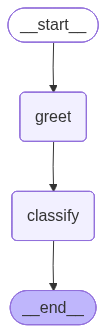

In [30]:
from IPython.display import Image, display

try:
    display(Image(simple_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(simple_graph.get_graph().draw_mermaid())

Adding Conditional Routing

In [31]:
from typing import Literal, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI

# LLM with Responses API for custom graph usage
llm = ChatOpenAI(model=MODEL, temperature=0, use_responses_api=True, api_key=api_key)

class SupportState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: str

# ----- Node: Classify intent using LLM -----
def classify_intent(state: SupportState):
    last_msg = state["messages"][-1].content if state["messages"] else ""

    classification_prompt = [
        SystemMessage(content="""Classify the customer message into exactly one category.
Reply with ONLY the category name, nothing else.
Categories: faq, order_tracking, complaint, general"""),
        HumanMessage(content=last_msg)
    ]

    result = llm.invoke(classification_prompt)
    intent = result.text.strip().lower()

    # Normalize
    if "faq" in intent:
        intent = "faq"
    elif "order" in intent or "track" in intent:
        intent = "order_tracking"
    elif "complaint" in intent:
        intent = "complaint"
    else:
        intent = "general"

    return {"intent": intent}

# ----- Node: Handle FAQ -----
def handle_faq(state: SupportState):
    last_msg = state["messages"][-1].content
    llm_with_faq = llm.bind_tools([faq_lookup])
    response = llm_with_faq.invoke([
        SystemMessage(content="Answer the customer's FAQ question using the faq_lookup tool. Be helpful and concise."),
        HumanMessage(content=last_msg)
    ])

    if response.tool_calls:
        tool_result = faq_lookup.invoke(response.tool_calls[0]["args"])
        final = llm.invoke([
            SystemMessage(content="Rewrite this FAQ answer in a friendly customer-support tone:"),
            HumanMessage(content=tool_result)
        ])
        return {"messages": [AIMessage(content=final.content)]}

    return {"messages": [response]}

# ----- Node: Handle Order Tracking -----
def handle_order(state: SupportState):
    last_msg = state["messages"][-1].content
    llm_with_tracker = llm.bind_tools([order_tracker])
    response = llm_with_tracker.invoke([
        SystemMessage(content="Track the customer's order using the order_tracker tool. Extract the order ID from their message."),
        HumanMessage(content=last_msg)
    ])

    if response.tool_calls:
        tool_result = order_tracker.invoke(response.tool_calls[0]["args"])
        final = llm.invoke([
            SystemMessage(content="Present this order tracking info in a friendly way:"),
            HumanMessage(content=tool_result)
        ])
        return {"messages": [AIMessage(content=final.content)]}

    return {"messages": [response]}

# ----- Node: Handle Complaint -----
def handle_complaint(state: SupportState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="You are NovaMart support. The customer has a complaint. Acknowledge their frustration, apologize sincerely, and offer to escalate. Be empathetic."),
        HumanMessage(content=last_msg)
    ])
    return {"messages": [response]}

# ----- Node: Handle General -----
def handle_general(state: SupportState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="You are NovaMart's friendly support agent. Answer the customer's general question helpfully."),
        HumanMessage(content=last_msg)
    ])
    return {"messages": [response]}

# ----- Router function -----
def route_by_intent(state: SupportState) -> Literal["handle_faq", "handle_order", "handle_complaint", "handle_general"]:
    intent = state.get("intent", "general")
    mapping = {
        "faq": "handle_faq",
        "order_tracking": "handle_order",
        "complaint": "handle_complaint",
        "general": "handle_general"
    }
    return mapping.get(intent, "handle_general")

# ----- Build the graph -----
builder = StateGraph(SupportState)

builder.add_node("classify", classify_intent)
builder.add_node("handle_faq", handle_faq)
builder.add_node("handle_order", handle_order)
builder.add_node("handle_complaint", handle_complaint)
builder.add_node("handle_general", handle_general)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_by_intent)
builder.add_edge("handle_faq", END)
builder.add_edge("handle_order", END)
builder.add_edge("handle_complaint", END)
builder.add_edge("handle_general", END)

custom_agent = builder.compile()

print("✅ Custom NovaMart support graph built!")

✅ Custom NovaMart support graph built!


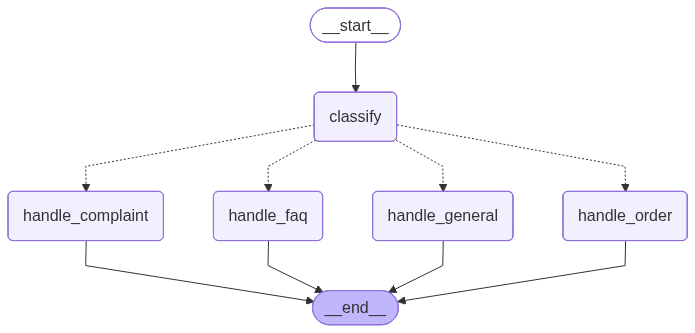

In [34]:
from IPython.display import Image, display

try:
    display(Image(custom_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(custom_agent.get_graph().draw_mermaid())

In [33]:
result = custom_agent.invoke({
    "messages": [HumanMessage(content="What's your return policy?")],
    "intent": ""
})
print("📋 FAQ Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

📋 FAQ Test
Intent: faq
🤖 Agent: We’ve got you covered at NovaMart. If you’re not completely happy, you can return any item within 30 days—no questions asked—as long as it’s in its original packaging. If you’d like help starting a return or have any questions, we’re here to assist.

